# CAIPH Datathon: Stroke Prediction Dataset
Author: Annika Cleven (ed: Vincent Toups)
Date: 2026-02-04

Research Question:

Can we identify meaningful sub-groups in stroke victims?

Welcome the CAIPH Datathon!

You are looking at A Stroke Dataset provided by user fedesoriano on
Kaggle. The paper "Predictive modelling and identification of key risk
factors for stroke using machine learning" by Ahmad Hassan, Saima
Gulzar Ahmad, Ehsan Ullah Munir, Imtiaz Ali Khan & Naeem Ramzan
available [here](https://www.nature.com/articles/s41598-024-61665-4#Sec3) provides a good
introduction to the data set and might be a place to look for ideas
about how to proceed with analysis. It describes the data set like this:

> The stroke prediction dataset was created by McKinsey & Company and Kaggle is the source of the data used in this study38,39. The dataset is in comma separated values (CSV) format, including demographic and health-related information about individuals and whether or not they have had a stroke. The dataset was originally comprised a total of 29,072 records, while only 30% of the data is publicly accessible and the remaining 70% is designated as private. The source of the dataset is mentioned as confidential. The data originates from medical records associated with 5110 individuals residing in Bangladesh. The dataset has underwent preprocessing procedures, which involved modifications to the original dataset sourced from Electronic Health Records (EHR) managed by McKinsey & Company. The data has some missing values, and there is an imbalance between the number of people who have had a stroke and those who have not. The aim is to address these issues using different data imputation techniques and oversampling methods.


## Setup

In [1]:
# Load required packages (add others as needed)
install.packages(c("themis"))

ensure_library <- function(pkg) {
  pkg_name <- deparse(substitute(pkg))
  if (!requireNamespace(pkg_name, quietly = TRUE)) {
    install.packages(pkg_name)
  }
  library(pkg_name, character.only = TRUE)
}

ensure_library(tidyverse)
ensure_library(knitr)
ensure_library(factoextra)
ensure_library(tidymodels)
ensure_library(themis)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Warning message:
“dependencies ‘ggrepel’, ‘pbkrtest’, ‘Matrix’ are not available”
also installing the dependencies ‘rbibutils’, ‘SparseM’, ‘MatrixModels’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘Rdpack’, ‘RcppEigen’, ‘lazyeval’, ‘later’, ‘otel’, ‘carData’, ‘abind’, ‘Formula’, ‘quantreg’, ‘lme4’, ‘crosstalk’, ‘htmlw

ERROR: Error in library(pkg_name, character.only = TRUE): there is no package called ‘factoextra’


We can load our data set and look at it just like this:

In [3]:
stroke <- read_csv("/data/stroke/healthcare-dataset-stroke-data.csv")
stroke

Rows: 5110 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): gender, ever_married, work_type, Residence_type, bmi, smoking_status
dbl (6): id, age, hypertension, heart_disease, avg_glucose_level, stroke

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>
9046,Male,67,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
51676,Female,61,0,0,Yes,Self-employed,Rural,202.21,N/A,never smoked,1
31112,Male,80,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
60182,Female,49,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
1665,Female,79,1,0,Yes,Self-employed,Rural,174.12,24,never smoked,1
56669,Male,81,0,0,Yes,Private,Urban,186.21,29,formerly smoked,1
53882,Male,74,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
10434,Female,69,0,0,No,Private,Urban,94.39,22.8,never smoked,1
27419,Female,59,0,0,Yes,Private,Rural,76.15,N/A,Unknown,1


## Tidying up and Preliminary Examination

We often have to tidy up the data. Here we are fixing a few issues with how missing data is encoded and creating 
factor variables, which is how we tell R that we have categorical variables instead of just raw text.


In [4]:
stroke2 <- stroke %>% 
  mutate(across(where(is.character), as.factor),
         across(where(is.logical), as.factor)) %>%
  mutate(bmi = ifelse(bmi == "N/A", NA, bmi)) %>%
  mutate(bmi = as.numeric(bmi),
         hypertension = as.factor(hypertension),
         heart_disease = as.factor(heart_disease),
         stroke = as.factor(stroke))
 
stroke_counts <- stroke2 %>%
  select(where(~ is.factor(.) | is.character(.))) %>%
  pivot_longer(everything(),
               names_to = "variable",
               values_to = "category") %>%
  count(variable, category, name = "n") %>%
  arrange(variable, desc(n))

stroke_counts

variable,category,n
<chr>,<fct>,<int>
Residence_type,Urban,2596
Residence_type,Rural,2514
ever_married,Yes,3353
ever_married,No,1757
gender,Female,2994
gender,Male,2115
gender,Other,1
heart_disease,0,4834
heart_disease,1,276


Note that this data is highly imbalanced, since most people have not had a stroke in this data set.

Warning message in geom_histogram(stat = "count", fill = "blue"):
“Ignoring unknown parameters: `binwidth` and `bins`”


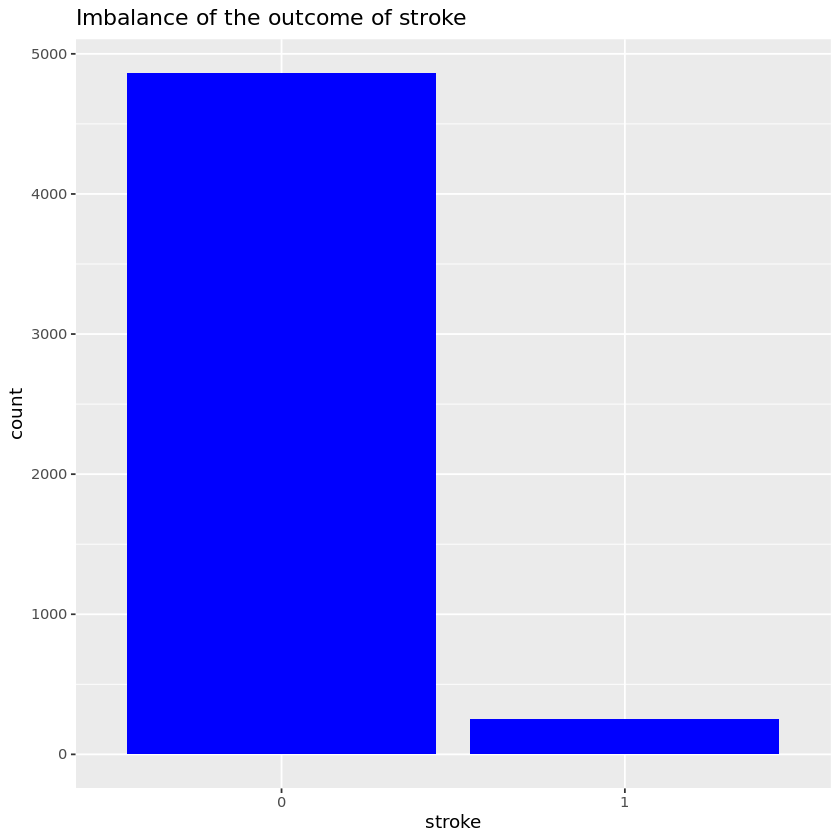

In [5]:
stroke2 %>% 
  ggplot(aes(stroke))+ 
  geom_histogram(stat = "count", fill = "blue")+
  labs(title = "Imbalance of the outcome of stroke")

Let's make a few bar chards showing risk factors against stroke.

Adding missing grouping variables: `stroke`


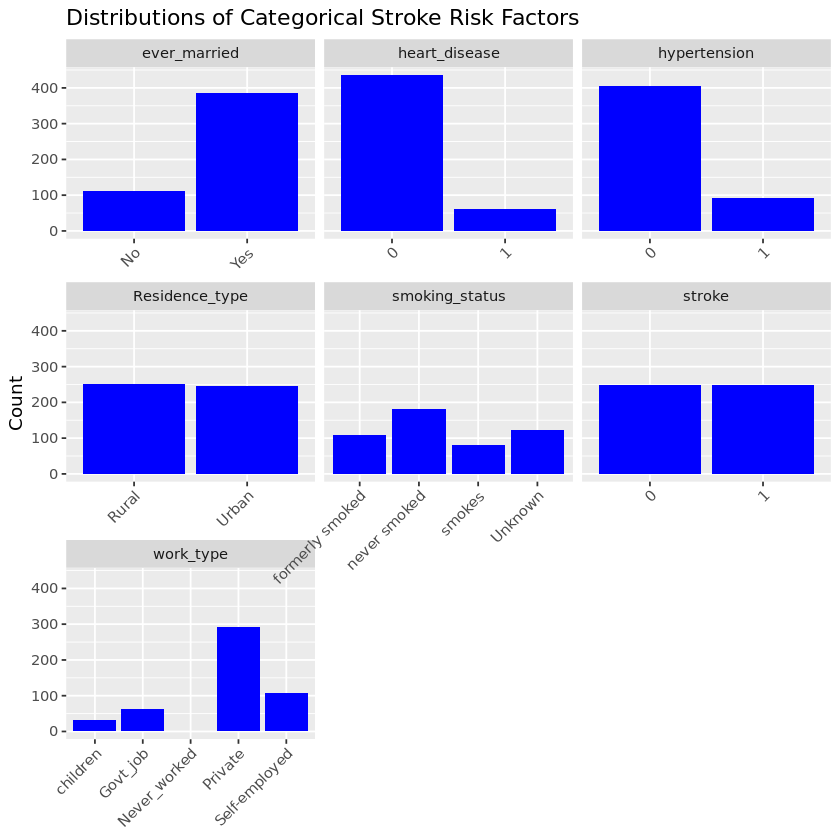

In [9]:
stroke2 %>% group_by(stroke) %>% filter(row_number()<nrow(stroke2 %>% filter(stroke==1))) %>%
  select(Residence_type, ever_married, heart_disease,
         hypertension, work_type, smoking_status) %>%
  pivot_longer(everything(),
               names_to = "variable",
               values_to = "category") %>%
  ggplot(aes(x = category)) +
  geom_bar(fill = "blue") +
  facet_wrap(~ variable, scales = "free_x") +
  labs(
    title = "Distributions of Categorical Stroke Risk Factors",
    x = NULL,
    y = "Count"
  ) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

And calculate how much data is missing.

In [12]:
missing_summary <- stroke2 %>%
  summarise(across(everything(),
                   ~ sum(is.na(.)),
                   .names = "na_{col}")) %>%
  pivot_longer(everything(),
               names_to = "variable",
               values_to = "n_missing")

missing_summary %>%
  filter(n_missing > 0) %>%
  mutate(pct_missing = n_missing / nrow(stroke) * 100) %>%
  kable()

missing_summary



|variable | n_missing| pct_missing|
|:--------|---------:|-----------:|
|na_bmi   |       201|    3.933464|

variable,n_missing
<chr>,<int>
na_id,0
na_gender,0
na_age,0
na_hypertension,0
na_heart_disease,0
na_ever_married,0
na_work_type,0
na_Residence_type,0
na_avg_glucose_level,0


A reasonable place to start would be doing dimensionality reduction - PCA is the simplest method.